In [16]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Harsh\OneDrive\Desktop\Streamlit Deployment\Churn_Modelling (1).xlsx")
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
# Check for null values
print("Null values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Check data types
print("\nData types of each column:")
df.info()

Null values in each column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Number of duplicate rows:
0

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  fl

In [18]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=columns_to_drop, axis=1)

print("DataFrame after dropping columns:")
display(df.head())
print(f"New DataFrame shape: {df.shape}")

DataFrame after dropping columns:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


New DataFrame shape: (10000, 11)


Box plots for numerical columns to visualize outliers:


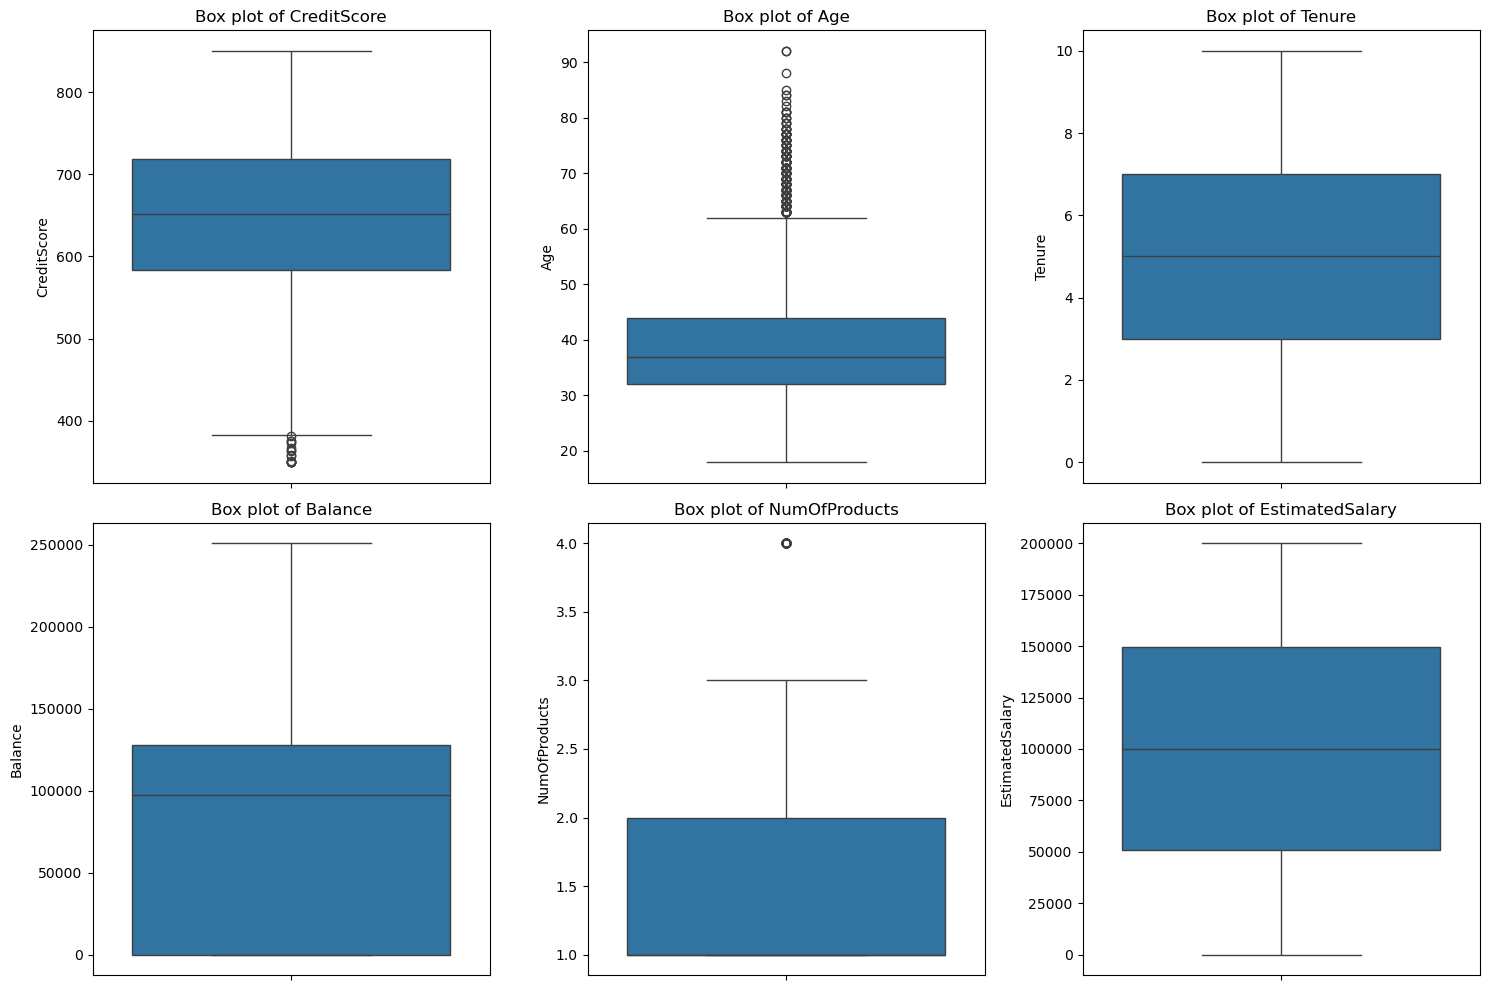


Column 'CreditScore': 15 outliers detected.
Outliers in 'CreditScore' treated by capping (values replaced with lower/upper bounds).

Column 'Age': 359 outliers detected.
Outliers in 'Age' treated by capping (values replaced with lower/upper bounds).

Column 'Tenure': No significant outliers detected using IQR method.

Column 'Balance': No significant outliers detected using IQR method.

Column 'NumOfProducts': 60 outliers detected.
Outliers in 'NumOfProducts' treated by capping (values replaced with lower/upper bounds).

Column 'EstimatedSalary': No significant outliers detected using IQR method.

DataFrame after outlier treatment:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.561300,38.660800,5.012800,76485.889288,1.527200,0.70550,0.515100,100090.239881,0.203700
std,96.558702,9.746704,2.892174,62397.405202,0.570081,0.45584,0.499797,57510.492818,0.402769
min,383.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,62.000000,10.000000,250898.090000,3.500000,1.00000,1.000000,199992.480000,1.000000


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to check for outliers
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

print("Box plots for numerical columns to visualize outliers:")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

# Outlier detection and treatment using IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    if outliers_count > 0:
        print(f"\nColumn '{col}': {outliers_count} outliers detected.")
        # Capping outliers: replace values outside bounds with the bounds themselves
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"Outliers in '{col}' treated by capping (values replaced with lower/upper bounds).")
    else:
        print(f"\nColumn '{col}': No significant outliers detected using IQR method.")

print("\nDataFrame after outlier treatment:")
display(df.describe())

In [20]:
print("\nClass distribution of the target variable 'Exited':")
print(df['Exited'].value_counts())
print("\nPercentage of each class:")
print(df['Exited'].value_counts(normalize=True) * 100)


Class distribution of the target variable 'Exited':
Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage of each class:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [21]:
# Separate features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (10000, 10)
Target (y) shape: (10000,)


Next, we need to handle categorical features. 'Geography' and 'Gender' are categorical, so we'll apply one-hot encoding using `pd.get_dummies`.

In [22]:
# One-hot encode categorical features
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

print("Features (X) shape after one-hot encoding:", X.shape)
display(X.head())

Features (X) shape after one-hot encoding: (10000, 11)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1.0,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1.0,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3.0,1,0,113931.57,False,False,False
3,699,39,1,0.00,2.0,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1.0,1,1,79084.10,False,True,False


Now, we will apply SMOTE to balance the dataset. First, we need to install the `imbalanced-learn` library if it's not already installed.

In [23]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [24]:
from imblearn.over_sampling import SMOTE

smt = SMOTE(random_state=42)
X_resampled, y_resampled = smt.fit_resample(X, y)

print("Shape of X after SMOTE:", X_resampled.shape)
print("Shape of y after SMOTE:", y_resampled.shape)

print("\nClass distribution after SMOTE:")
print(y_resampled.value_counts())

Shape of X after SMOTE: (15926, 11)
Shape of y after SMOTE: (15926,)

Class distribution after SMOTE:
Exited
1    7963
0    7963
Name: count, dtype: int64


The dataset is now balanced. The next steps would typically involve splitting the data into training and testing sets, scaling numerical features, and then training a machine learning model.

In [25]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (12740, 11)
X_test shape: (3186, 11)
y_train shape: (12740,)
y_test shape: (3186,)


In [26]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
# Exclude one-hot encoded and already binary columns
numerical_cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaler to training data
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Apply scaler to test data (using the scaler fitted on training data)
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features in X_train and X_test have been scaled.")
display(X_train.head())

Numerical features in X_train and X_test have been scaled.


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
915,-0.580273,0.661960,0.433065,-1.325652,-0.851810,1,0,-0.440525,False,False,True
2987,0.293969,-1.565078,-1.406509,0.436846,-0.851810,0,0,-0.694319,True,False,False
3666,0.567170,-2.095325,1.536809,-1.325652,0.838864,1,1,-1.283525,False,True,False
6336,-1.235955,-0.610633,-0.302764,0.651109,-0.851810,0,0,-0.399811,True,False,False
14282,-1.388948,0.237762,-0.670679,-1.325652,-0.851810,0,0,0.800869,False,True,True


In [27]:
print("One-hot encoding for 'Geography' and 'Gender' has already been performed.")
print("You can see the encoded columns in X_train.head():")
display(X_train.head())

One-hot encoding for 'Geography' and 'Gender' has already been performed.
You can see the encoded columns in X_train.head():


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
915,-0.580273,0.661960,0.433065,-1.325652,-0.851810,1,0,-0.440525,False,False,True
2987,0.293969,-1.565078,-1.406509,0.436846,-0.851810,0,0,-0.694319,True,False,False
3666,0.567170,-2.095325,1.536809,-1.325652,0.838864,1,1,-1.283525,False,True,False
6336,-1.235955,-0.610633,-0.302764,0.651109,-0.851810,0,0,-0.399811,True,False,False
14282,-1.388948,0.237762,-0.670679,-1.325652,-0.851810,0,0,0.800869,False,True,True


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize and train the Random Forest Classifier model with pruning parameters
# max_depth: Limits the depth of each tree, helping prevent overfitting.
# min_samples_leaf: Ensures that each leaf has a minimum number of samples, also preventing overfitting.
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_leaf=5)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classifier Model Evaluation (with pruning parameters):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classifier Model Evaluation (with pruning parameters):
Accuracy: 0.8663
Precision: 0.8903
Recall: 0.8355
F1-Score: 0.8620

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1593
           1       0.89      0.84      0.86      1593

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186


Confusion Matrix:
[[1429  164]
 [ 262 1331]]


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Define the parameter grid to search with reduced options for faster execution
param_grid = {
    'n_estimators': [100, 200], # Reduced number of trees
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': [10, 20],  # Reduced max depth options
    'min_samples_split': [5, 10],  # Reduced min samples to split
    'min_samples_leaf': [2, 4]     # Reduced min samples per leaf
}

# Initialize the Random Forest Classifier
rf_base = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
# We'll use 'f1' as the scoring metric since we're dealing with a balanced dataset now after SMOTE
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=2)

print("Starting GridSearchCV for Random Forest...")
grid_search.fit(X_train, y_train)

print("\nBest parameters found:", grid_search.best_params_)
print("Best F1-Score found:", grid_search.best_score_)

# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned_rf = best_rf_model.predict(X_test)

print("\nRandom Forest Classifier Model Evaluation (after Hyperparameter Tuning):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_rf))

Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters found: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-Score found: 0.8835823819871566

Random Forest Classifier Model Evaluation (after Hyperparameter Tuning):
Accuracy: 0.8879
Precision: 0.9093
Recall: 0.8619
F1-Score: 0.8850

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1593
           1       0.91      0.86      0.88      1593

    accuracy                           0.89      3186
   macro avg       0.89      0.89      0.89      3186
weighted avg       0.89      0.89      0.89      3186


Confusion Matrix:
[[1456  137]
 [ 220 1373]]


In [30]:
import pickle
# save model
pickle.dump(best_rf_model, open("chrun_model.pkl", "wb"))